In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
# 1. Define 2D Grid Environment
grid_size = 5
goal_state = (4, 4)

actions = {
    0: (-1, 0),  # up
    1: (1, 0),   # down
    2: (0, -1),  # left
    3: (0, 1)    # right
}

n_actions = len(actions)

In [3]:
# 2. Initialize Q-table (state: (row, col), action space)
Q = np.zeros((grid_size, grid_size, n_actions))

# 3. Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 500

In [4]:
# 4. Step function
def step(state, action):
    r, c = state
    dr, dc = actions[action]
    
    nr = max(0, min(grid_size - 1, r + dr))
    nc = max(0, min(grid_size - 1, c + dc))
    
    next_state = (nr, nc)
    
    # Rewards
    if next_state == goal_state:
        reward = 10
        done = True
    else:
        reward = -1
        done = False
    
    return next_state, reward, done

In [5]:
# 5. Training
episode_rewards = []

for ep in range(episodes):
    state = (0, 0)
    total_reward = 0
    
    while True:
        r, c = state
        
        # ε-greedy
        if random.uniform(0, 1) < epsilon:
            action = random.choice(list(actions.keys()))
        else:
            action = np.argmax(Q[r, c])
        
        next_state, reward, done = step(state, action)
        nr, nc = next_state
        
        # Q update
        Q[r, c, action] += alpha * (
            reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action]
        )
        
        state = next_state
        total_reward += reward
        
        if done:
            break
    
    episode_rewards.append(total_reward)

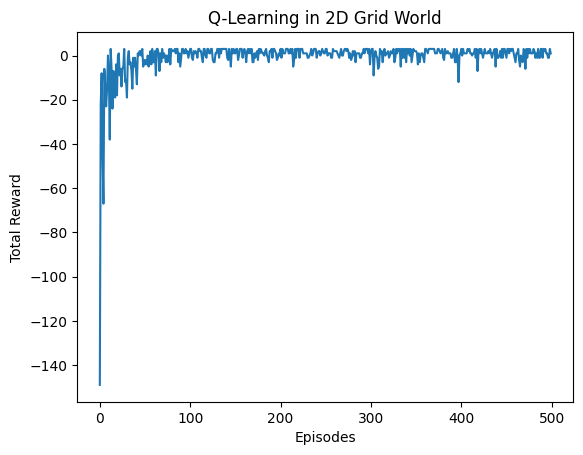

In [6]:
# 6. Plot learning curve
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-Learning in 2D Grid World")
plt.show()


Optimal Path:
[(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]


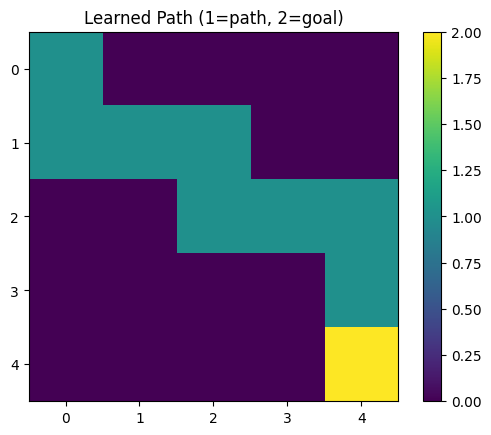

In [7]:
# 7. Show optimal path
state = (0, 0)
path = [state]

while state != goal_state:
    r, c = state
    action = np.argmax(Q[r, c])
    state, _, _ = step(state, action)
    path.append(state)

print("\nOptimal Path:")
print(path)

# 8. Visualize path on grid
grid = np.zeros((grid_size, grid_size))

for (r, c) in path:
    grid[r, c] = 1

grid[goal_state] = 2  # mark goal

plt.figure()
plt.imshow(grid)
plt.title("Learned Path (1=path, 2=goal)")
plt.colorbar()
plt.show()